y_HY3 shape: (956, 1)
y_HY43 shape: (980, 1)


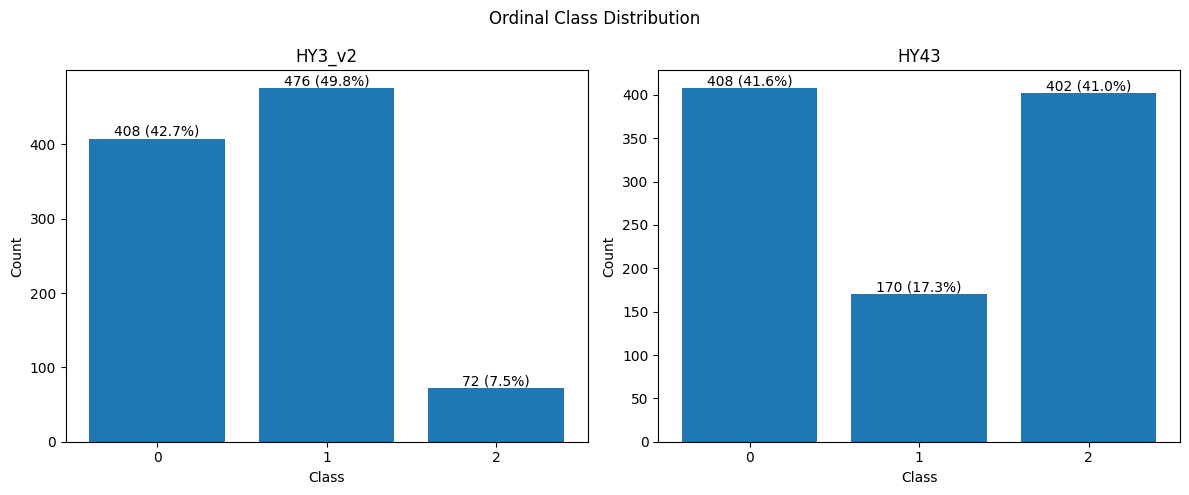

In [2]:
import pandas as pd
import json
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parents[3]

import matplotlib.pyplot as plt


y_HY3_v2 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY3_v2_final.csv", index_col=0)
y_HY43 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY43_v2_final.csv", index_col=0)
print("y_HY3 shape:", y_HY3_v2.shape)
print("y_HY43 shape:", y_HY43.shape)


datasets = {
    "HY3_v2": y_HY3_v2,
    'HY43': y_HY43  # Asegúrate de tener este dataset definido
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    
    counts = df.iloc[:,0].value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    
    bars = ax.bar(counts.index.astype(str), counts.values)
    
    # añadir texto con conteo y porcentaje
    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(i, count, f"{count} ({pct:.1f}%)", 
                ha='center', va='bottom')
    
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.suptitle("Ordinal Class Distribution")
plt.tight_layout()
plt.show()

In [3]:
import os
import re

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/Domain_data.json", "r") as archivo:
    full_domain = json.load(archivo)

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/UPDRS_Domain_data.json", "r") as archivo:
    updrs_domain = json.load(archivo)

X_multiples_HY3= {'X_STATS_V2':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_stats_v2_final_HY3.csv',
                'X_VX_STATS_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_stats_v2_final_HY3.csv',
                'X_VX_DELTA_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_delta_v2_final_HY3.csv'}

y_multiples_HY3 = { 'HY3_v2': project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY3_v2_final.csv",
                'HY3_v2_sampled': project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY3_v2_Sampled_HY3.csv",
                }

X_multiples_HY43= {'X_STATS_V2':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_stats_v2_final_HY43.csv',
                        'X_VX_STATS_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_stats_v2_final_HY43.csv',
                        'X_VX_DELTA_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_delta_v2_final_HY43.csv', }

y_multiples_HY43 = { 'HY43_v2': project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY43_v2_final.csv"}


pairs_init_HY3=[('X_STATS_V2', 'HY3_v2'),
        ('X_VX_STATS_V2', 'HY3_v2'),
        ('X_VX_DELTA_V2', 'HY3_v2')]

pairs_init_HY43=[('X_STATS_V2', 'HY43_v2'),
        ('X_VX_STATS_V2', 'HY43_v2'),
        ('X_VX_DELTA_V2', 'HY43_v2')]


output_path= project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/Multiclass/V2_analysis/"

In [4]:
for val1,val2 in pairs_init_HY3:
    print(f"Evaluating pair: {val1} and {val2}")
    X=pd.read_csv(X_multiples_HY3[val1],index_col=0)
    print(f"Shape of X: {X.shape}")

Evaluating pair: X_STATS_V2 and HY3_v2
Shape of X: (956, 301)
Evaluating pair: X_VX_STATS_V2 and HY3_v2
Shape of X: (956, 360)
Evaluating pair: X_VX_DELTA_V2 and HY3_v2
Shape of X: (956, 242)


# HY3

Distribución original:
STAGE_HY3
0    408
1    476
2     72
Name: count, dtype: int64

Bloque reservado para modelo multiclase:
STAGE_HY3
0    72
1    72
2    72
Name: count, dtype: int64

Bloque para modelo binario (solo 0 y 1 restantes):
STAGE_HY3
0    336
1    404
Name: count, dtype: int64

Distribución modelo multiclase:
Train: {0: 43, 1: 42, 2: 43}
Val  : {0: 8, 1: 8, 2: 7}
Test : {0: 21, 1: 22, 2: 22}

Entrenando modelo binario 0 vs 1
[001] train_loss=0.5155 | val_loss=0.3266 | val_acc=0.9189 | val_f1=0.9241
[010] train_loss=0.0164 | val_loss=0.3958 | val_acc=0.8919 | val_f1=0.9024
Early stopping en epoch 18

Resultados validación modelo binario:
Loss: 0.2197
Acc : 0.8851
F1  : 0.8957

Entrenando modelo multiclase - fase 1 (head)
[001] train_loss=0.9415 | val_loss=0.8480 | val_acc=0.7391 | val_f1_macro=0.7157 | val_recall_2=1.0000
[010] train_loss=0.6819 | val_loss=0.7542 | val_acc=0.6957 | val_f1_macro=0.6928 | val_recall_2=0.5714
[020] train_loss=0.6579 | val_loss=0.7485 | val_

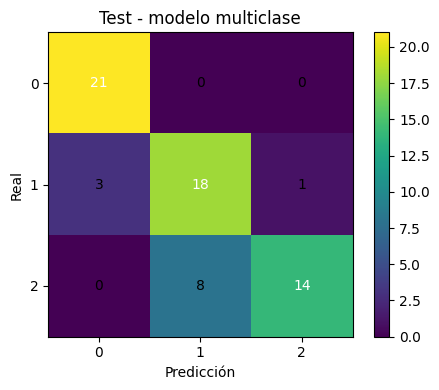


Pipeline completado y guardado.


In [11]:
# =========================================================
# PIPELINE COMPLETO EN PYTORCH
# 1) Reservar 72 de clase 0, 72 de clase 1 y 72 de clase 2
# 2) Entrenar modelo binario SOLO con clases 0 y 1 restantes
# 3) Transferir pesos a un modelo multiclase
# 4) Entrenar modelo multiclase con el bloque reservado
# 5) Evaluar con métricas y matriz de confusión
# =========================================================

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# =========================
# CONFIG
# =========================
SEED = 42
TARGET_COL = "STAGE_HY3"
BATCH_SIZE = 16
HIDDEN_DIMS = (128, 64)
DROPOUT = 0.30

# Entrenamiento modelo binario
BIN_LR = 1e-3
BIN_EPOCHS = 100
BIN_PATIENCE = 15

# Entrenamiento modelo multiclase - fase 1 (solo cabeza)
HEAD_LR = 1e-3
HEAD_EPOCHS = 40
HEAD_PATIENCE = 10

# Entrenamiento modelo multiclase - fase 2 (fine-tuning completo)
FT_LR = 3e-4
FT_EPOCHS = 80
FT_PATIENCE = 15

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# UTILIDADES
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

def make_loader(X, y, batch_size=32, shuffle=False, task="multiclass"):
    X_t = torch.tensor(X, dtype=torch.float32)
    if task == "binary":
        y_t = torch.tensor(y, dtype=torch.float32)
    else:
        y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32), dropout=0.2, num_classes=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Linear(hidden_dims[1], num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.head(x)
        return x

def set_feature_extractor_trainable(model, trainable=True):
    for p in model.feature_extractor.parameters():
        p.requires_grad = trainable

@torch.no_grad()
def evaluate(model, loader, criterion, task="binary"):
    model.eval()

    total_loss = 0.0
    n_samples = 0

    y_true_all = []
    y_pred_all = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)

        if task == "binary":
            logits = logits.squeeze(1)
            loss = criterion(logits, yb)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()
            y_true_all.extend(yb.cpu().numpy().astype(int))
            y_pred_all.extend(preds.cpu().numpy().astype(int))
        else:
            loss = criterion(logits, yb)
            preds = torch.argmax(logits, dim=1)
            y_true_all.extend(yb.cpu().numpy())
            y_pred_all.extend(preds.cpu().numpy())

        total_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)

    avg_loss = total_loss / n_samples
    acc = accuracy_score(y_true_all, y_pred_all)

    if task == "binary":
        f1 = f1_score(y_true_all, y_pred_all, average="binary", zero_division=0)
        metrics = {
            "loss": avg_loss,
            "acc": acc,
            "f1": f1,
            "y_true": np.array(y_true_all),
            "y_pred": np.array(y_pred_all),
        }
    else:
        f1_macro = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        recalls = recall_score(y_true_all, y_pred_all, average=None, labels=[0, 1, 2], zero_division=0)
        metrics = {
            "loss": avg_loss,
            "acc": acc,
            "f1_macro": f1_macro,
            "recall_0": recalls[0],
            "recall_1": recalls[1],
            "recall_2": recalls[2],
            "y_true": np.array(y_true_all),
            "y_pred": np.array(y_pred_all),
        }

    return metrics

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    task="binary",
    epochs=100,
    patience=15,
    verbose=True,
):
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)

            if task == "binary":
                logits = logits.squeeze(1)
                loss = criterion(logits, yb)
            else:
                loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            n_samples += xb.size(0)

        train_loss = running_loss / n_samples
        val_metrics = evaluate(model, val_loader, criterion, task=task)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
        }

        if task == "binary":
            row["val_acc"] = val_metrics["acc"]
            row["val_f1"] = val_metrics["f1"]
        else:
            row["val_acc"] = val_metrics["acc"]
            row["val_f1_macro"] = val_metrics["f1_macro"]
            row["val_recall_2"] = val_metrics["recall_2"]

        history.append(row)

        if verbose and (epoch == 1 or epoch % 10 == 0):
            if task == "binary":
                print(
                    f"[{epoch:03d}] "
                    f"train_loss={train_loss:.4f} | "
                    f"val_loss={val_metrics['loss']:.4f} | "
                    f"val_acc={val_metrics['acc']:.4f} | "
                    f"val_f1={val_metrics['f1']:.4f}"
                )
            else:
                print(
                    f"[{epoch:03d}] "
                    f"train_loss={train_loss:.4f} | "
                    f"val_loss={val_metrics['loss']:.4f} | "
                    f"val_acc={val_metrics['acc']:.4f} | "
                    f"val_f1_macro={val_metrics['f1_macro']:.4f} | "
                    f"val_recall_2={val_metrics['recall_2']:.4f}"
                )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping en epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

def plot_confusion_matrix(cm, class_names=("0", "1", "2"), title="Matriz de confusión"):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicción",
        ylabel="Real",
        title=title,
    )

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )
    plt.tight_layout()
    plt.show()


# =========================================================
# 0) CARGA DE DATOS
# =========================================================
# EJEMPLO:
X=pd.read_csv(X_multiples_HY3['X_VX_DELTA_V2'],index_col=0)
y=pd.read_csv(y_multiples_HY3['HY3_v2'],index_col=0)
df = pd.concat([X, y], axis=1)
df.reset_index(drop=True, inplace=True)



feature_cols = [c for c in df.columns if c != TARGET_COL]

# Comprobaciones básicas
assert TARGET_COL in df.columns, f"No existe la columna objetivo '{TARGET_COL}'"
assert set(df[TARGET_COL].unique()).issubset({0, 1, 2}), "Las clases deben ser 0, 1 y 2"

print("Distribución original:")
print(df[TARGET_COL].value_counts().sort_index())

assert (df[TARGET_COL] == 0).sum() >= 72, "No hay al menos 72 muestras de clase 0"
assert (df[TARGET_COL] == 1).sum() >= 72, "No hay al menos 72 muestras de clase 1"
assert (df[TARGET_COL] == 2).sum() >= 72, "No hay al menos 72 muestras de clase 2"

# =========================================================
# 1) RESERVAR 72 DE CADA CLASE PARA EL MODELO MULTICLASE
# =========================================================
idx0 = df[df[TARGET_COL] == 0].sample(n=72, random_state=SEED).index
idx1 = df[df[TARGET_COL] == 1].sample(n=72, random_state=SEED).index
idx2 = df[df[TARGET_COL] == 2].sample(n=72, random_state=SEED).index

reserved_idx = np.concatenate([idx0.to_numpy(), idx1.to_numpy(), idx2.to_numpy()])

reserved_df = df.loc[reserved_idx].copy()
binary_df = df.loc[(~df.index.isin(reserved_idx)) & (df[TARGET_COL].isin([0, 1]))].copy()

print("\nBloque reservado para modelo multiclase:")
print(reserved_df[TARGET_COL].value_counts().sort_index())

print("\nBloque para modelo binario (solo 0 y 1 restantes):")
print(binary_df[TARGET_COL].value_counts().sort_index())

# =========================================================
# 2) SPLITS
# =========================================================
# ---- Modelo binario: split train/val para early stopping
X_bin = binary_df[feature_cols].astype(np.float32).values
y_bin = binary_df[TARGET_COL].astype(np.float32).values  # 0 o 1

Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_bin, y_bin,
    test_size=0.20,
    stratify=y_bin,
    random_state=SEED
)

# ---- Modelo multiclase: 70% train / 30% test
X_res = reserved_df[feature_cols].astype(np.float32).values
y_res = reserved_df[TARGET_COL].astype(np.int64).values  # 0,1,2

X2_train_full, X2_test, y2_train_full, y2_test = train_test_split(
    X_res, y_res,
    test_size=0.30,
    stratify=y_res,
    random_state=SEED
)

# Del 70% train, sacamos una pequeña validación interna
X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2_train_full, y2_train_full,
    test_size=0.15,
    stratify=y2_train_full,
    random_state=SEED
)

print("\nDistribución modelo multiclase:")
print("Train:", pd.Series(y2_train).value_counts().sort_index().to_dict())
print("Val  :", pd.Series(y2_val).value_counts().sort_index().to_dict())
print("Test :", pd.Series(y2_test).value_counts().sort_index().to_dict())

# =========================================================
# 3) ESCALADO
# =========================================================
# IMPORTANTE:
# Para que la transferencia tenga sentido, usamos el MISMO scaler
# ajustado con el train del modelo binario.
scaler = StandardScaler()

Xb_train = scaler.fit_transform(Xb_train)
Xb_val   = scaler.transform(Xb_val)

X2_train = scaler.transform(X2_train)
X2_val   = scaler.transform(X2_val)
X2_test  = scaler.transform(X2_test)

# =========================================================
# 4) DATALOADERS
# =========================================================
bin_train_loader = make_loader(Xb_train, yb_train, batch_size=BATCH_SIZE, shuffle=True, task="binary")
bin_val_loader   = make_loader(Xb_val,   yb_val,   batch_size=BATCH_SIZE, shuffle=False, task="binary")

mc_train_loader = make_loader(X2_train, y2_train, batch_size=BATCH_SIZE, shuffle=True, task="multiclass")
mc_val_loader   = make_loader(X2_val,   y2_val,   batch_size=BATCH_SIZE, shuffle=False, task="multiclass")
mc_test_loader  = make_loader(X2_test,  y2_test,  batch_size=BATCH_SIZE, shuffle=False, task="multiclass")

# =========================================================
# 5) MODELO 1: BINARIO (0 vs 1)
# =========================================================
input_dim = Xb_train.shape[1]

binary_model = TabularMLP(
    input_dim=input_dim,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    num_classes=1
).to(DEVICE)

criterion_bin = nn.BCEWithLogitsLoss()
optimizer_bin = torch.optim.Adam(
    binary_model.parameters(),
    lr=BIN_LR,
    weight_decay=1e-4
)

print("\n==============================")
print("Entrenando modelo binario 0 vs 1")
print("==============================")

binary_model, hist_bin = train_model(
    model=binary_model,
    train_loader=bin_train_loader,
    val_loader=bin_val_loader,
    criterion=criterion_bin,
    optimizer=optimizer_bin,
    task="binary",
    epochs=BIN_EPOCHS,
    patience=BIN_PATIENCE,
    verbose=True,
)

bin_val_metrics = evaluate(binary_model, bin_val_loader, criterion_bin, task="binary")

print("\nResultados validación modelo binario:")
print(f"Loss: {bin_val_metrics['loss']:.4f}")
print(f"Acc : {bin_val_metrics['acc']:.4f}")
print(f"F1  : {bin_val_metrics['f1']:.4f}")

# Guardar extractor de características si quieres reutilizarlo luego
torch.save(binary_model.feature_extractor.state_dict(), "feature_extractor_binario_0_1.pt")

# =========================================================
# 6) MODELO 2: MULTICLASE CON TRANSFER LEARNING
# =========================================================
multiclass_model = TabularMLP(
    input_dim=input_dim,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    num_classes=3
).to(DEVICE)

# Cargar pesos del extractor aprendido en el binario
multiclass_model.feature_extractor.load_state_dict(
    binary_model.feature_extractor.state_dict()
)

weights = torch.tensor([1.0, 2.5, 1], dtype=torch.float32).to(DEVICE)
criterion_mc = nn.CrossEntropyLoss(weight=weights)
# -------------------------
# FASE 1: congelar extractor y entrenar solo la cabeza
# -------------------------
set_feature_extractor_trainable(multiclass_model, trainable=False)

optimizer_head = torch.optim.Adam(
    filter(lambda p: p.requires_grad, multiclass_model.parameters()),
    lr=HEAD_LR,
    weight_decay=1e-4
)

print("\n==============================================")
print("Entrenando modelo multiclase - fase 1 (head)")
print("==============================================")

multiclass_model, hist_head = train_model(
    model=multiclass_model,
    train_loader=mc_train_loader,
    val_loader=mc_val_loader,
    criterion=criterion_mc,
    optimizer=optimizer_head,
    task="multiclass",
    epochs=HEAD_EPOCHS,
    patience=HEAD_PATIENCE,
    verbose=True,
)

# -------------------------
# FASE 2: descongelar todo y fine-tuning
# -------------------------
set_feature_extractor_trainable(multiclass_model, trainable=True)

optimizer_ft = torch.optim.Adam(
    multiclass_model.parameters(),
    lr=FT_LR,
    weight_decay=1e-4
)

print("\n==================================================")
print("Entrenando modelo multiclase - fase 2 (fine-tuning)")
print("==================================================")

multiclass_model, hist_ft = train_model(
    model=multiclass_model,
    train_loader=mc_train_loader,
    val_loader=mc_val_loader,
    criterion=criterion_mc,
    optimizer=optimizer_ft,
    task="multiclass",
    epochs=FT_EPOCHS,
    patience=FT_PATIENCE,
    verbose=True,
)

# =========================================================
# 7) EVALUACIÓN FINAL EN TEST DEL MODELO MULTICLASE
# =========================================================
test_metrics = evaluate(multiclass_model, mc_test_loader, criterion_mc, task="multiclass")

print("\n==============================")
print("TEST FINAL MODELO MULTICLASE")
print("==============================")
print(f"Loss           : {test_metrics['loss']:.4f}")
print(f"Accuracy       : {test_metrics['acc']:.4f}")
print(f"F1 macro       : {test_metrics['f1_macro']:.4f}")
print(f"Recall clase 0 : {test_metrics['recall_0']:.4f}")
print(f"Recall clase 1 : {test_metrics['recall_1']:.4f}")
print(f"Recall clase 2 : {test_metrics['recall_2']:.4f}")

y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]

print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
print("Matriz de confusión:")
print(cm)

plot_confusion_matrix(cm, class_names=("0", "1", "2"), title="Test - modelo multiclase")

# =========================================================
# 8) GUARDAR MODELO FINAL
# =========================================================
torch.save({
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
    "feature_cols": feature_cols,
    "binary_feature_extractor_state_dict": binary_model.feature_extractor.state_dict(),
    "multiclass_model_state_dict": multiclass_model.state_dict(),
}, "pipeline_transfer_tabular_pytorch.pt")

print("\nPipeline completado y guardado.")

---


Distribución global modelo multiclase (bloque reservado):
{0: 72, 1: 72, 2: 72}

Entrenando modelo binario 0 vs 1
[001] train_loss=0.5210 | val_loss=0.3590 | val_acc=0.8851 | val_f1=0.8931
[010] train_loss=0.0090 | val_loss=0.3862 | val_acc=0.8784 | val_f1=0.8889
Early stopping en epoch 18

Resultados validación modelo binario:
Loss: 0.2250
Acc : 0.8919
F1  : 0.9024

FOLD 1/10
Distribución fold:
Train: {0: 51, 1: 52, 2: 52}
Val  : {0: 13, 1: 13, 2: 13}
Test : {0: 8, 1: 7, 2: 7}

Resultados fold 1:
Loss           : 0.5883
Accuracy       : 0.7727
F1 macro       : 0.7578
Recall clase 0 : 1.0000
Recall clase 1 : 0.5714
Recall clase 2 : 0.7143
Matriz de confusión del fold:
[[8 0 0]
 [2 4 1]
 [0 2 5]]

FOLD 2/10
Distribución fold:
Train: {0: 51, 1: 52, 2: 52}
Val  : {0: 13, 1: 13, 2: 13}
Test : {0: 8, 1: 7, 2: 7}

Resultados fold 2:
Loss           : 0.5554
Accuracy       : 0.7727
F1 macro       : 0.7745
Recall clase 0 : 0.8750
Recall clase 1 : 0.7143
Recall clase 2 : 0.7143
Matriz de confus

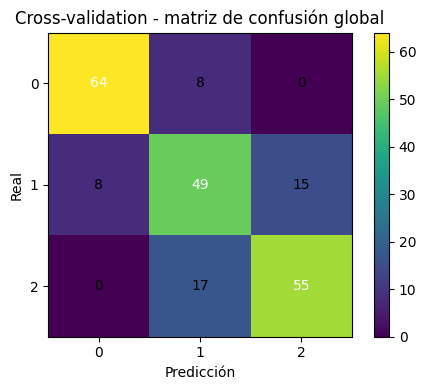


Cross-validation completado y resultados guardados.


In [12]:
# =========================================================
# 2) SPLITS + CROSS-VALIDATION MULTICLASE
# =========================================================
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 10

# ---- Modelo binario: split train/val para early stopping
X_bin = binary_df[feature_cols].astype(np.float32).values
y_bin = binary_df[TARGET_COL].astype(np.float32).values  # 0 o 1

Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_bin, y_bin,
    test_size=0.20,
    stratify=y_bin,
    random_state=SEED
)

# ---- Datos del bloque reservado para CV multiclase
X_res = reserved_df[feature_cols].astype(np.float32).values
y_res = reserved_df[TARGET_COL].astype(np.int64).values  # 0,1,2

print("\nDistribución global modelo multiclase (bloque reservado):")
print(pd.Series(y_res).value_counts().sort_index().to_dict())

# =========================================================
# 3) ESCALADO
# =========================================================
# IMPORTANTE:
# mantenemos tu lógica: el scaler se ajusta SOLO con el train binario
scaler = StandardScaler()

Xb_train = scaler.fit_transform(Xb_train)
Xb_val   = scaler.transform(Xb_val)

# =========================================================
# 4) DATALOADERS BINARIOS
# =========================================================
bin_train_loader = make_loader(Xb_train, yb_train, batch_size=BATCH_SIZE, shuffle=True, task="binary")
bin_val_loader   = make_loader(Xb_val,   yb_val,   batch_size=BATCH_SIZE, shuffle=False, task="binary")

# =========================================================
# 5) MODELO 1: BINARIO (0 vs 1)
# =========================================================
input_dim = Xb_train.shape[1]

binary_model = TabularMLP(
    input_dim=input_dim,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    num_classes=1
).to(DEVICE)

criterion_bin = nn.BCEWithLogitsLoss()
optimizer_bin = torch.optim.Adam(
    binary_model.parameters(),
    lr=BIN_LR,
    weight_decay=1e-4
)

print("\n==============================")
print("Entrenando modelo binario 0 vs 1")
print("==============================")

binary_model, hist_bin = train_model(
    model=binary_model,
    train_loader=bin_train_loader,
    val_loader=bin_val_loader,
    criterion=criterion_bin,
    optimizer=optimizer_bin,
    task="binary",
    epochs=BIN_EPOCHS,
    patience=BIN_PATIENCE,
    verbose=True,
)

bin_val_metrics = evaluate(binary_model, bin_val_loader, criterion_bin, task="binary")

print("\nResultados validación modelo binario:")
print(f"Loss: {bin_val_metrics['loss']:.4f}")
print(f"Acc : {bin_val_metrics['acc']:.4f}")
print(f"F1  : {bin_val_metrics['f1']:.4f}")

# Guardar extractor de características si quieres reutilizarlo luego
torch.save(binary_model.feature_extractor.state_dict(), "feature_extractor_binario_0_1.pt")

# =========================================================
# 6) CROSS-VALIDATION DEL MODELO MULTICLASE
# =========================================================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

cv_results = []
all_y_true = []
all_y_pred = []
fold_confusions = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_res, y_res), start=1):
    print("\n" + "=" * 60)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("=" * 60)

    # reproducibilidad por fold
    set_seed(SEED + fold)

    # ---------------------------------
    # split externo del fold: train/test
    # ---------------------------------
    X_fold_train_full = X_res[train_idx]
    y_fold_train_full = y_res[train_idx]

    X_fold_test = X_res[test_idx]
    y_fold_test = y_res[test_idx]

    # ---------------------------------
    # split interno: train/val para early stopping
    # ---------------------------------
    X_fold_train, X_fold_val, y_fold_train, y_fold_val = train_test_split(
        X_fold_train_full,
        y_fold_train_full,
        test_size=0.20,
        stratify=y_fold_train_full,
        random_state=SEED
    )

    print("Distribución fold:")
    print("Train:", pd.Series(y_fold_train).value_counts().sort_index().to_dict())
    print("Val  :", pd.Series(y_fold_val).value_counts().sort_index().to_dict())
    print("Test :", pd.Series(y_fold_test).value_counts().sort_index().to_dict())

    # ---------------------------------
    # usar el MISMO scaler del binario
    # ---------------------------------
    X_fold_train = scaler.transform(X_fold_train)
    X_fold_val   = scaler.transform(X_fold_val)
    X_fold_test  = scaler.transform(X_fold_test)

    # ---------------------------------
    # dataloaders multiclase
    # ---------------------------------
    mc_train_loader = make_loader(
        X_fold_train, y_fold_train,
        batch_size=BATCH_SIZE, shuffle=True, task="multiclass"
    )
    mc_val_loader = make_loader(
        X_fold_val, y_fold_val,
        batch_size=BATCH_SIZE, shuffle=False, task="multiclass"
    )
    mc_test_loader = make_loader(
        X_fold_test, y_fold_test,
        batch_size=BATCH_SIZE, shuffle=False, task="multiclass"
    )

    # ---------------------------------
    # modelo multiclase nuevo para este fold
    # ---------------------------------
    multiclass_model = TabularMLP(
        input_dim=input_dim,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
        num_classes=3
    ).to(DEVICE)

    # cargar pesos del extractor binario
    multiclass_model.feature_extractor.load_state_dict(
        binary_model.feature_extractor.state_dict()
    )

    # pesos de clase (mantengo tu mejora para la clase 1)
    weights = torch.tensor([1.0, 2.5, 1.0], dtype=torch.float32).to(DEVICE)
    criterion_mc = nn.CrossEntropyLoss(weight=weights)

    # -------------------------
    # FASE 1: congelar extractor y entrenar solo la cabeza
    # -------------------------
    set_feature_extractor_trainable(multiclass_model, trainable=False)

    optimizer_head = torch.optim.Adam(
        filter(lambda p: p.requires_grad, multiclass_model.parameters()),
        lr=HEAD_LR,
        weight_decay=1e-4
    )

    multiclass_model, hist_head = train_model(
        model=multiclass_model,
        train_loader=mc_train_loader,
        val_loader=mc_val_loader,
        criterion=criterion_mc,
        optimizer=optimizer_head,
        task="multiclass",
        epochs=HEAD_EPOCHS,
        patience=HEAD_PATIENCE,
        verbose=False,
    )

    # -------------------------
    # FASE 2: descongelar todo y fine-tuning
    # -------------------------
    set_feature_extractor_trainable(multiclass_model, trainable=True)

    optimizer_ft = torch.optim.Adam(
        multiclass_model.parameters(),
        lr=FT_LR,
        weight_decay=1e-4
    )

    multiclass_model, hist_ft = train_model(
        model=multiclass_model,
        train_loader=mc_train_loader,
        val_loader=mc_val_loader,
        criterion=criterion_mc,
        optimizer=optimizer_ft,
        task="multiclass",
        epochs=FT_EPOCHS,
        patience=FT_PATIENCE,
        verbose=False,
    )

    # -------------------------
    # evaluación del fold
    # -------------------------
    fold_metrics = evaluate(multiclass_model, mc_test_loader, criterion_mc, task="multiclass")

    print(f"\nResultados fold {fold}:")
    print(f"Loss           : {fold_metrics['loss']:.4f}")
    print(f"Accuracy       : {fold_metrics['acc']:.4f}")
    print(f"F1 macro       : {fold_metrics['f1_macro']:.4f}")
    print(f"Recall clase 0 : {fold_metrics['recall_0']:.4f}")
    print(f"Recall clase 1 : {fold_metrics['recall_1']:.4f}")
    print(f"Recall clase 2 : {fold_metrics['recall_2']:.4f}")

    y_true_fold = fold_metrics["y_true"]
    y_pred_fold = fold_metrics["y_pred"]

    cm_fold = confusion_matrix(y_true_fold, y_pred_fold, labels=[0, 1, 2])
    print("Matriz de confusión del fold:")
    print(cm_fold)

    cv_results.append({
        "fold": fold,
        "loss": fold_metrics["loss"],
        "acc": fold_metrics["acc"],
        "f1_macro": fold_metrics["f1_macro"],
        "recall_0": fold_metrics["recall_0"],
        "recall_1": fold_metrics["recall_1"],
        "recall_2": fold_metrics["recall_2"],
    })

    all_y_true.extend(y_true_fold.tolist())
    all_y_pred.extend(y_pred_fold.tolist())
    fold_confusions.append(cm_fold)

# =========================================================
# 7) RESUMEN FINAL DE CROSS-VALIDATION
# =========================================================
cv_results_df = pd.DataFrame(cv_results)

print("\n==============================")
print("RESULTADOS CROSS-VALIDATION")
print("==============================")
print(cv_results_df)

print("\nPromedio de métricas:")
print(cv_results_df[["loss", "acc", "f1_macro", "recall_0", "recall_1", "recall_2"]].mean())

print("\nDesviación estándar:")
print(cv_results_df[["loss", "acc", "f1_macro", "recall_0", "recall_1", "recall_2"]].std())

print("\nClassification report global (todos los folds juntos):")
print(classification_report(all_y_true, all_y_pred, digits=4, zero_division=0))

cm_global = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1, 2])
print("Matriz de confusión global:")
print(cm_global)

plot_confusion_matrix(
    cm_global,
    class_names=("0", "1", "2"),
    title="Cross-validation - matriz de confusión global"
)

# =========================================================
# 8) GUARDAR RESULTADOS CV
# =========================================================
cv_results_df.to_csv("cv_results_multiclass_transfer.csv", index=False)

torch.save({
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
    "feature_cols": feature_cols,
    "binary_feature_extractor_state_dict": binary_model.feature_extractor.state_dict(),
    "cv_results": cv_results,
    "global_confusion_matrix": cm_global,
}, "pipeline_transfer_tabular_cv_results.pt")

print("\nCross-validation completado y resultados guardados.")

In [21]:
import copy
import json
import random
import warnings
from dataclasses import dataclass, asdict, replace
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")


# =========================================================
# CONFIGURACIÓN BASE
# =========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEFAULT_TARGET_COL = "STAGE_HY3"
DEFAULT_OUTPUT_DIR = Path("resultados_experimentos_transfer")


@dataclass
class ExperimentConfig:
    # Datos
    target_col: str = DEFAULT_TARGET_COL
    batch_size: int = 16
    reserved_per_class: int = 72
    test_size_multiclass: float = 0.30
    val_size_multiclass_from_train: float = 0.15
    val_size_binary: float = 0.20
    scaler_strategy: str = "binary_train"  # binary_train, multiclass_train, none

    # Modelo
    hidden_dims: Tuple[int, int] = (64, 32)
    dropout: float = 0.10

    # Entrenamiento binario
    bin_lr: float = 1e-3
    bin_epochs: int = 100
    bin_patience: int = 15

    # Entrenamiento multiclase - fase 1 (solo cabeza)
    head_lr: float = 1e-3
    head_epochs: int = 40
    head_patience: int = 10

    # Entrenamiento multiclase - fase 2 (fine-tuning)
    ft_lr: float = 3e-4
    ft_epochs: int = 80
    ft_patience: int = 15

    # Regularización
    weight_decay: float = 1e-4
    multiclass_weights: Tuple[float, float, float] = (1.0, 2.0, 1.0)

    # Banderas de experimento
    use_transfer: bool = True
    transfer_mode: str = "all"  # none, all, first_layer
    phase1_freeze: bool = True
    phase2_finetune: bool = True
    use_class_weights: bool = True
    train_from_scratch_same_budget: bool = False

    # Control
    verbose: bool = True
    save_plots: bool = True
    output_dir: Path = DEFAULT_OUTPUT_DIR


# =========================================================
# UTILIDADES GENERALES
# =========================================================
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def ensure_output_dir(output_dir: Path) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)


def make_loader(X: np.ndarray, y: np.ndarray, batch_size: int = 32, shuffle: bool = False, task: str = "multiclass") -> DataLoader:
    X_t = torch.tensor(X, dtype=torch.float32)
    if task == "binary":
        y_t = torch.tensor(y, dtype=torch.float32)
    else:
        y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


class TabularMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: Tuple[int, int] = (64, 32), dropout: float = 0.2, num_classes: int = 1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Linear(hidden_dims[1], num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.feature_extractor(x)
        x = self.head(x)
        return x


def set_feature_extractor_trainable(model: nn.Module, trainable: bool = True) -> None:
    for p in model.feature_extractor.parameters():
        p.requires_grad = trainable


def load_transfer_weights(target_model: TabularMLP, source_model: TabularMLP, mode: str = "all") -> None:
    if mode == "none":
        return
    if mode == "all":
        target_model.feature_extractor.load_state_dict(source_model.feature_extractor.state_dict())
        return
    if mode == "first_layer":
        # Copia solo la primera capa lineal del extractor
        target_model.feature_extractor[0].weight.data.copy_(source_model.feature_extractor[0].weight.data)
        target_model.feature_extractor[0].bias.data.copy_(source_model.feature_extractor[0].bias.data)
        return
    raise ValueError(f"Modo de transferencia no soportado: {mode}")


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, task: str = "binary") -> Dict[str, np.ndarray]:
    model.eval()

    total_loss = 0.0
    n_samples = 0
    y_true_all: List[int] = []
    y_pred_all: List[int] = []
    y_prob_all: List[np.ndarray] = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)

        if task == "binary":
            logits = logits.squeeze(1)
            loss = criterion(logits, yb)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()
            y_true_all.extend(yb.cpu().numpy().astype(int))
            y_pred_all.extend(preds.cpu().numpy().astype(int))
            y_prob_all.extend(probs.cpu().numpy().reshape(-1, 1))
        else:
            loss = criterion(logits, yb)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            y_true_all.extend(yb.cpu().numpy())
            y_pred_all.extend(preds.cpu().numpy())
            y_prob_all.extend(probs.cpu().numpy())

        total_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)

    avg_loss = total_loss / max(n_samples, 1)
    y_true = np.array(y_true_all)
    y_pred = np.array(y_pred_all)
    y_prob = np.array(y_prob_all)

    result = {
        "loss": avg_loss,
        "acc": accuracy_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

    if task == "binary":
        result.update({
            "f1": f1_score(y_true, y_pred, average="binary", zero_division=0),
            "precision": precision_score(y_true, y_pred, average="binary", zero_division=0),
            "recall": recall_score(y_true, y_pred, average="binary", zero_division=0),
        })
    else:
        result.update({
            "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        })
        for cls in [0, 1, 2]:
            result[f"recall_{cls}"] = recall_score(y_true, y_pred, labels=[cls], average="macro", zero_division=0)
            result[f"precision_{cls}"] = precision_score(y_true, y_pred, labels=[cls], average="macro", zero_division=0)

    return result


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    task: str = "binary",
    epochs: int = 100,
    patience: int = 15,
    verbose: bool = True,
) -> Tuple[nn.Module, pd.DataFrame]:
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)

            if task == "binary":
                logits = logits.squeeze(1)
                loss = criterion(logits, yb)
            else:
                loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            n_samples += xb.size(0)

        train_loss = running_loss / max(n_samples, 1)
        val_metrics = evaluate(model, val_loader, criterion, task=task)

        row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_metrics["loss"], "val_acc": val_metrics["acc"]}
        if task == "binary":
            row.update({"val_f1": val_metrics["f1"], "val_balanced_acc": val_metrics["balanced_acc"]})
        else:
            row.update({
                "val_f1_macro": val_metrics["f1_macro"],
                "val_f1_weighted": val_metrics["f1_weighted"],
                "val_balanced_acc": val_metrics["balanced_acc"],
                "val_recall_0": val_metrics["recall_0"],
                "val_recall_1": val_metrics["recall_1"],
                "val_recall_2": val_metrics["recall_2"],
            })

        history.append(row)

        if verbose and (epoch == 1 or epoch % 10 == 0):
            if task == "binary":
                print(
                    f"[{epoch:03d}] train_loss={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
                    f"val_acc={val_metrics['acc']:.4f} | val_f1={val_metrics['f1']:.4f}"
                )
            else:
                print(
                    f"[{epoch:03d}] train_loss={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
                    f"val_acc={val_metrics['acc']:.4f} | val_f1_macro={val_metrics['f1_macro']:.4f} | "
                    f"val_recall_2={val_metrics['recall_2']:.4f}"
                )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping en epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def plot_confusion_matrix(cm: np.ndarray, class_names: Sequence[str] = ("0", "1", "2"), title: str = "Matriz de confusión", save_path: Optional[Path] = None) -> None:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicción",
        ylabel="Real",
        title=title,
    )

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


# =========================================================
# PREPARACIÓN DE DATOS
# =========================================================
def validate_dataframe(df: pd.DataFrame, target_col: str) -> None:
    assert target_col in df.columns, f"No existe la columna objetivo '{target_col}'"
    unique_classes = set(pd.Series(df[target_col]).dropna().unique())
    assert unique_classes.issubset({0, 1, 2}), f"Las clases deben ser 0, 1 y 2. Encontradas: {sorted(unique_classes)}"



def split_reserved_binary(df: pd.DataFrame, cfg: ExperimentConfig, seed: int) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
    validate_dataframe(df, cfg.target_col)
    feature_cols = [c for c in df.columns if c != cfg.target_col]

    for cls in [0, 1, 2]:
        available = int((df[cfg.target_col] == cls).sum())
        assert available >= cfg.reserved_per_class, (
            f"No hay suficientes muestras de clase {cls}. Disponibles={available}, requeridas={cfg.reserved_per_class}"
        )

    idx0 = df[df[cfg.target_col] == 0].sample(n=cfg.reserved_per_class, random_state=seed).index
    idx1 = df[df[cfg.target_col] == 1].sample(n=cfg.reserved_per_class, random_state=seed).index
    idx2 = df[df[cfg.target_col] == 2].sample(n=cfg.reserved_per_class, random_state=seed).index

    reserved_idx = np.concatenate([idx0.to_numpy(), idx1.to_numpy(), idx2.to_numpy()])
    reserved_df = df.loc[reserved_idx].copy().reset_index(drop=True)
    binary_df = df.loc[(~df.index.isin(reserved_idx)) & (df[cfg.target_col].isin([0, 1]))].copy().reset_index(drop=True)

    assert len(feature_cols) > 0, "No se encontraron columnas de entrada"
    assert len(binary_df) > 0, "El bloque binario quedó vacío"

    return reserved_df, binary_df, feature_cols



def make_experiment_splits(df: pd.DataFrame, cfg: ExperimentConfig, seed: int) -> Dict[str, np.ndarray]:
    reserved_df, binary_df, feature_cols = split_reserved_binary(df, cfg, seed)

    # Binario: solo clases 0 y 1
    X_bin = binary_df[feature_cols].astype(np.float32).values
    y_bin = binary_df[cfg.target_col].astype(np.float32).values

    Xb_train, Xb_val, yb_train, yb_val = train_test_split(
        X_bin,
        y_bin,
        test_size=cfg.val_size_binary,
        stratify=y_bin,
        random_state=seed,
    )

    # Multiclase sobre el bloque reservado
    X_res = reserved_df[feature_cols].astype(np.float32).values
    y_res = reserved_df[cfg.target_col].astype(np.int64).values

    X2_train_full, X2_test, y2_train_full, y2_test = train_test_split(
        X_res,
        y_res,
        test_size=cfg.test_size_multiclass,
        stratify=y_res,
        random_state=seed,
    )

    X2_train, X2_val, y2_train, y2_val = train_test_split(
        X2_train_full,
        y2_train_full,
        test_size=cfg.val_size_multiclass_from_train,
        stratify=y2_train_full,
        random_state=seed,
    )

    # Escalado
    if cfg.scaler_strategy == "binary_train":
        scaler = StandardScaler()
        Xb_train_sc = scaler.fit_transform(Xb_train)
        Xb_val_sc = scaler.transform(Xb_val)
        X2_train_sc = scaler.transform(X2_train)
        X2_val_sc = scaler.transform(X2_val)
        X2_test_sc = scaler.transform(X2_test)
        scaler_info = {"strategy": "binary_train", "mean": getattr(scaler, "mean_", None), "scale": getattr(scaler, "scale_", None)}
    elif cfg.scaler_strategy == "multiclass_train":
        scaler_bin = StandardScaler()
        Xb_train_sc = scaler_bin.fit_transform(Xb_train)
        Xb_val_sc = scaler_bin.transform(Xb_val)

        scaler_mc = StandardScaler()
        X2_train_sc = scaler_mc.fit_transform(X2_train)
        X2_val_sc = scaler_mc.transform(X2_val)
        X2_test_sc = scaler_mc.transform(X2_test)
        scaler_info = {
            "strategy": "multiclass_train",
            "binary_mean": getattr(scaler_bin, "mean_", None),
            "binary_scale": getattr(scaler_bin, "scale_", None),
            "multiclass_mean": getattr(scaler_mc, "mean_", None),
            "multiclass_scale": getattr(scaler_mc, "scale_", None),
        }
    elif cfg.scaler_strategy == "none":
        Xb_train_sc, Xb_val_sc = Xb_train, Xb_val
        X2_train_sc, X2_val_sc, X2_test_sc = X2_train, X2_val, X2_test
        scaler_info = {"strategy": "none"}
    else:
        raise ValueError(f"Estrategia de escalado no soportada: {cfg.scaler_strategy}")

    return {
        "feature_cols": feature_cols,
        "input_dim": Xb_train_sc.shape[1],
        "reserved_df": reserved_df,
        "binary_df": binary_df,
        "Xb_train": Xb_train_sc,
        "Xb_val": Xb_val_sc,
        "yb_train": yb_train,
        "yb_val": yb_val,
        "X2_train": X2_train_sc,
        "X2_val": X2_val_sc,
        "X2_test": X2_test_sc,
        "y2_train": y2_train,
        "y2_val": y2_val,
        "y2_test": y2_test,
        "scaler_info": scaler_info,
    }



def make_loaders_from_split(split: Dict[str, np.ndarray], cfg: ExperimentConfig) -> Dict[str, DataLoader]:
    return {
        "bin_train_loader": make_loader(split["Xb_train"], split["yb_train"], batch_size=cfg.batch_size, shuffle=True, task="binary"),
        "bin_val_loader": make_loader(split["Xb_val"], split["yb_val"], batch_size=cfg.batch_size, shuffle=False, task="binary"),
        "mc_train_loader": make_loader(split["X2_train"], split["y2_train"], batch_size=cfg.batch_size, shuffle=True, task="multiclass"),
        "mc_val_loader": make_loader(split["X2_val"], split["y2_val"], batch_size=cfg.batch_size, shuffle=False, task="multiclass"),
        "mc_test_loader": make_loader(split["X2_test"], split["y2_test"], batch_size=cfg.batch_size, shuffle=False, task="multiclass"),
    }


# =========================================================
# BLOQUES DE ENTRENAMIENTO
# =========================================================
def build_binary_model(input_dim: int, cfg: ExperimentConfig) -> TabularMLP:
    return TabularMLP(
        input_dim=input_dim,
        hidden_dims=cfg.hidden_dims,
        dropout=cfg.dropout,
        num_classes=1,
    ).to(DEVICE)



def build_multiclass_model(input_dim: int, cfg: ExperimentConfig) -> TabularMLP:
    return TabularMLP(
        input_dim=input_dim,
        hidden_dims=cfg.hidden_dims,
        dropout=cfg.dropout,
        num_classes=3,
    ).to(DEVICE)



def get_multiclass_criterion(cfg: ExperimentConfig) -> nn.Module:
    if cfg.use_class_weights:
        weights = torch.tensor(cfg.multiclass_weights, dtype=torch.float32).to(DEVICE)
        return nn.CrossEntropyLoss(weight=weights)
    return nn.CrossEntropyLoss()



def pretrain_binary_model(split: Dict[str, np.ndarray], loaders: Dict[str, DataLoader], cfg: ExperimentConfig) -> Tuple[TabularMLP, pd.DataFrame, Dict[str, float]]:
    binary_model = build_binary_model(split["input_dim"], cfg)
    criterion_bin = nn.BCEWithLogitsLoss()
    optimizer_bin = torch.optim.Adam(binary_model.parameters(), lr=cfg.bin_lr, weight_decay=cfg.weight_decay)

    if cfg.verbose:
        print("\n==============================")
        print("Entrenando modelo binario 0 vs 1")
        print("==============================")

    binary_model, hist_bin = train_model(
        model=binary_model,
        train_loader=loaders["bin_train_loader"],
        val_loader=loaders["bin_val_loader"],
        criterion=criterion_bin,
        optimizer=optimizer_bin,
        task="binary",
        epochs=cfg.bin_epochs,
        patience=cfg.bin_patience,
        verbose=cfg.verbose,
    )
    bin_val_metrics = evaluate(binary_model, loaders["bin_val_loader"], criterion_bin, task="binary")
    return binary_model, hist_bin, bin_val_metrics



def train_multiclass_pipeline(
    split: Dict[str, np.ndarray],
    loaders: Dict[str, DataLoader],
    cfg: ExperimentConfig,
    binary_model: Optional[TabularMLP] = None,
) -> Tuple[TabularMLP, Dict[str, pd.DataFrame], Dict[str, float]]:
    model = build_multiclass_model(split["input_dim"], cfg)
    criterion_mc = get_multiclass_criterion(cfg)
    histories: Dict[str, pd.DataFrame] = {}

    if cfg.use_transfer and binary_model is not None:
        load_transfer_weights(model, binary_model, mode=cfg.transfer_mode)

    # Caso "desde cero con mismo presupuesto"
    if (not cfg.use_transfer) and cfg.train_from_scratch_same_budget:
        if cfg.verbose:
            print("\n==============================================")
            print("Entrenando multiclase desde cero (mismo presupuesto)")
            print("==============================================")
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.ft_lr, weight_decay=cfg.weight_decay)
        total_epochs = cfg.head_epochs + cfg.ft_epochs
        total_patience = max(cfg.head_patience, cfg.ft_patience)
        model, hist = train_model(
            model=model,
            train_loader=loaders["mc_train_loader"],
            val_loader=loaders["mc_val_loader"],
            criterion=criterion_mc,
            optimizer=optimizer,
            task="multiclass",
            epochs=total_epochs,
            patience=total_patience,
            verbose=cfg.verbose,
        )
        histories["scratch_budget"] = hist
        test_metrics = evaluate(model, loaders["mc_test_loader"], criterion_mc, task="multiclass")
        return model, histories, test_metrics

    # Fase 1: solo cabeza
    if cfg.phase1_freeze:
        set_feature_extractor_trainable(model, trainable=False)
        optimizer_head = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.head_lr, weight_decay=cfg.weight_decay)
        if cfg.verbose:
            print("\n==============================================")
            print("Entrenando modelo multiclase - fase 1 (head)")
            print("==============================================")
        model, hist_head = train_model(
            model=model,
            train_loader=loaders["mc_train_loader"],
            val_loader=loaders["mc_val_loader"],
            criterion=criterion_mc,
            optimizer=optimizer_head,
            task="multiclass",
            epochs=cfg.head_epochs,
            patience=cfg.head_patience,
            verbose=cfg.verbose,
        )
        histories["head"] = hist_head

    # Fase 2: fine tuning completo
    if cfg.phase2_finetune:
        set_feature_extractor_trainable(model, trainable=True)
        optimizer_ft = torch.optim.Adam(model.parameters(), lr=cfg.ft_lr, weight_decay=cfg.weight_decay)
        if cfg.verbose:
            print("\n==================================================")
            print("Entrenando modelo multiclase - fase 2 (fine-tuning)")
            print("==================================================")
        model, hist_ft = train_model(
            model=model,
            train_loader=loaders["mc_train_loader"],
            val_loader=loaders["mc_val_loader"],
            criterion=criterion_mc,
            optimizer=optimizer_ft,
            task="multiclass",
            epochs=cfg.ft_epochs,
            patience=cfg.ft_patience,
            verbose=cfg.verbose,
        )
        histories["ft"] = hist_ft

    # Si no hubo ni fase 1 ni fase 2, entrenar una fase simple
    if (not cfg.phase1_freeze) and (not cfg.phase2_finetune):
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.ft_lr, weight_decay=cfg.weight_decay)
        if cfg.verbose:
            print("\n==================================================")
            print("Entrenando modelo multiclase - fase única")
            print("==================================================")
        model, hist = train_model(
            model=model,
            train_loader=loaders["mc_train_loader"],
            val_loader=loaders["mc_val_loader"],
            criterion=criterion_mc,
            optimizer=optimizer,
            task="multiclass",
            epochs=cfg.ft_epochs,
            patience=cfg.ft_patience,
            verbose=cfg.verbose,
        )
        histories["single_phase"] = hist

    test_metrics = evaluate(model, loaders["mc_test_loader"], criterion_mc, task="multiclass")
    return model, histories, test_metrics


# =========================================================
# EJECUCIÓN DE UN EXPERIMENTO
# =========================================================
def build_summary_row(exp_id: str, seed: int, cfg: ExperimentConfig, test_metrics: Dict[str, float], bin_metrics: Optional[Dict[str, float]] = None) -> Dict[str, float]:
    row = {
        "exp_id": exp_id,
        "seed": seed,
        "reserved_per_class": cfg.reserved_per_class,
        "hidden_dims": str(cfg.hidden_dims),
        "dropout": cfg.dropout,
        "bin_lr": cfg.bin_lr,
        "head_lr": cfg.head_lr,
        "ft_lr": cfg.ft_lr,
        "weight_decay": cfg.weight_decay,
        "scaler_strategy": cfg.scaler_strategy,
        "use_transfer": cfg.use_transfer,
        "transfer_mode": cfg.transfer_mode,
        "phase1_freeze": cfg.phase1_freeze,
        "phase2_finetune": cfg.phase2_finetune,
        "use_class_weights": cfg.use_class_weights,
        "multiclass_weights": str(cfg.multiclass_weights),
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["acc"],
        "test_balanced_acc": test_metrics["balanced_acc"],
        "test_f1_macro": test_metrics["f1_macro"],
        "test_f1_weighted": test_metrics["f1_weighted"],
        "test_precision_macro": test_metrics["precision_macro"],
        "test_recall_0": test_metrics["recall_0"],
        "test_recall_1": test_metrics["recall_1"],
        "test_recall_2": test_metrics["recall_2"],
        "test_precision_0": test_metrics["precision_0"],
        "test_precision_1": test_metrics["precision_1"],
        "test_precision_2": test_metrics["precision_2"],
    }
    if bin_metrics is not None:
        row.update({
            "bin_val_loss": bin_metrics["loss"],
            "bin_val_acc": bin_metrics["acc"],
            "bin_val_f1": bin_metrics["f1"],
            "bin_val_balanced_acc": bin_metrics["balanced_acc"],
        })
    return row



def save_experiment_outputs(
    exp_id: str,
    seed: int,
    cfg: ExperimentConfig,
    split: Dict[str, np.ndarray],
    hist_bin: Optional[pd.DataFrame],
    hist_multi: Dict[str, pd.DataFrame],
    test_metrics: Dict[str, float],
    model: nn.Module,
    binary_model: Optional[nn.Module],
) -> None:
    exp_dir = cfg.output_dir / exp_id / f"seed_{seed}"
    ensure_output_dir(exp_dir)

    if hist_bin is not None and not hist_bin.empty:
        hist_bin.to_csv(exp_dir / "hist_bin.csv", index=False)
    for name, hist in hist_multi.items():
        hist.to_csv(exp_dir / f"hist_{name}.csv", index=False)

    cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"], labels=[0, 1, 2])
    pd.DataFrame(cm, index=["real_0", "real_1", "real_2"], columns=["pred_0", "pred_1", "pred_2"]).to_csv(exp_dir / "confusion_matrix.csv")

    report = classification_report(test_metrics["y_true"], test_metrics["y_pred"], digits=4, zero_division=0, output_dict=True)
    with open(exp_dir / "classification_report.json", "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, ensure_ascii=False)

    if cfg.save_plots:
        plot_confusion_matrix(cm, title=f"{exp_id} | seed={seed}", save_path=exp_dir / "confusion_matrix.png")

    torch.save(
        {
            "config": asdict(cfg),
            "feature_cols": split["feature_cols"],
            "scaler_info": split["scaler_info"],
            "multiclass_model_state_dict": model.state_dict(),
            "binary_feature_extractor_state_dict": None if binary_model is None else binary_model.feature_extractor.state_dict(),
        },
        exp_dir / "modelo_final.pt",
    )



def run_single_experiment(df: pd.DataFrame, exp_id: str, seed: int, cfg: ExperimentConfig) -> Dict[str, float]:
    set_seed(seed)
    ensure_output_dir(cfg.output_dir)
    split = make_experiment_splits(df, cfg, seed)
    loaders = make_loaders_from_split(split, cfg)

    binary_model = None
    hist_bin = None
    bin_metrics = None

    if cfg.use_transfer:
        binary_model, hist_bin, bin_metrics = pretrain_binary_model(split, loaders, cfg)

    model, hist_multi, test_metrics = train_multiclass_pipeline(split, loaders, cfg, binary_model=binary_model)

    summary_row = build_summary_row(exp_id, seed, cfg, test_metrics, bin_metrics=bin_metrics)
    save_experiment_outputs(exp_id, seed, cfg, split, hist_bin, hist_multi, test_metrics, model, binary_model)
    return summary_row


# =========================================================
# DEFINICIÓN DE EXPERIMENTOS E0-E15
# =========================================================
def cfg_E0_baseline(base: ExperimentConfig) -> ExperimentConfig:
    return replace(base, use_transfer=True, transfer_mode="all", phase1_freeze=True, phase2_finetune=True, use_class_weights=True)


def cfg_E1_from_scratch(base: ExperimentConfig) -> ExperimentConfig:
    return replace(base, use_transfer=False, transfer_mode="none", phase1_freeze=False, phase2_finetune=False, use_class_weights=True)


def cfg_E2_no_freeze_phase1(base: ExperimentConfig) -> ExperimentConfig:
    return replace(base, use_transfer=True, transfer_mode="all", phase1_freeze=False, phase2_finetune=True, use_class_weights=True)


def cfg_E3_head_only(base: ExperimentConfig) -> ExperimentConfig:
    return replace(base, use_transfer=True, transfer_mode="all", phase1_freeze=True, phase2_finetune=False, use_class_weights=True)


def cfg_E4_no_class_weights(base: ExperimentConfig) -> ExperimentConfig:
    return replace(base, use_transfer=True, transfer_mode="all", phase1_freeze=True, phase2_finetune=True, use_class_weights=False)


def cfg_E5_alt_weights(base: ExperimentConfig, weights: Tuple[float, float, float]) -> ExperimentConfig:
    return replace(base, use_transfer=True, transfer_mode="all", phase1_freeze=True, phase2_finetune=True, use_class_weights=True, multiclass_weights=weights)


def cfg_E6_reserved_size(base: ExperimentConfig, reserved_per_class: int) -> ExperimentConfig:
    return replace(base, reserved_per_class=reserved_per_class)


def cfg_E8_architecture(base: ExperimentConfig, hidden_dims: Tuple[int, int]) -> ExperimentConfig:
    return replace(base, hidden_dims=hidden_dims)


def cfg_E9_dropout(base: ExperimentConfig, dropout: float) -> ExperimentConfig:
    return replace(base, dropout=dropout)


def cfg_E10_lrs(base: ExperimentConfig, bin_lr: float, head_lr: float, ft_lr: float) -> ExperimentConfig:
    return replace(base, bin_lr=bin_lr, head_lr=head_lr, ft_lr=ft_lr)


def cfg_E11_weight_decay(base: ExperimentConfig, weight_decay: float) -> ExperimentConfig:
    return replace(base, weight_decay=weight_decay)


def cfg_E12_scaler(base: ExperimentConfig, scaler_strategy: str) -> ExperimentConfig:
    return replace(base, scaler_strategy=scaler_strategy)


def cfg_E13_partial_transfer(base: ExperimentConfig, transfer_mode: str) -> ExperimentConfig:
    return replace(base, use_transfer=True, transfer_mode=transfer_mode)


def cfg_E14_scratch_same_budget(base: ExperimentConfig) -> ExperimentConfig:
    return replace(base, use_transfer=False, transfer_mode="none", phase1_freeze=False, phase2_finetune=False, train_from_scratch_same_budget=True)


# =========================================================
# RUNNERS DE BATERÍAS DE PRUEBAS
# =========================================================
def summarize_results(df_results: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [
        "test_acc", "test_balanced_acc", "test_f1_macro", "test_f1_weighted",
        "test_recall_0", "test_recall_1", "test_recall_2"
    ]
    summary = df_results.groupby("exp_id")[metric_cols].agg(["mean", "std", "min", "max"])
    summary.columns = [f"{a}_{b}" for a, b in summary.columns]
    return summary.reset_index()



def run_experiment_grid(df: pd.DataFrame, experiment_builders: List[Tuple[str, ExperimentConfig]], seeds: Sequence[int], output_csv: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for exp_name, cfg in experiment_builders:
        for seed in seeds:
            print(f"\n{'=' * 80}\nEjecutando {exp_name} | seed={seed}\n{'=' * 80}")
            row = run_single_experiment(df, exp_name, seed, cfg)
            rows.append(row)

    results = pd.DataFrame(rows)
    ensure_output_dir(output_csv.parent)
    results.to_csv(output_csv, index=False)
    summary = summarize_results(results)
    summary.to_csv(output_csv.with_name(output_csv.stem + "_summary.csv"), index=False)
    return results, summary


# =========================================================
# CROSS-VALIDATION (E15)
# =========================================================
def run_E15_stratified_kfold(df: pd.DataFrame, base_cfg: ExperimentConfig, seeds: Sequence[int], n_splits: int = 5, output_csv: Optional[Path] = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    cfg = cfg_E0_baseline(base_cfg)
    ensure_output_dir(cfg.output_dir)

    for seed in seeds:
        set_seed(seed)
        reserved_df, binary_df, feature_cols = split_reserved_binary(df, cfg, seed)

        # Preentrenamiento binario con el esquema estándar
        X_bin = binary_df[feature_cols].astype(np.float32).values
        y_bin = binary_df[cfg.target_col].astype(np.float32).values
        Xb_train, Xb_val, yb_train, yb_val = train_test_split(
            X_bin, y_bin, test_size=cfg.val_size_binary, stratify=y_bin, random_state=seed
        )

        if cfg.scaler_strategy == "binary_train":
            scaler_bin = StandardScaler()
            Xb_train_sc = scaler_bin.fit_transform(Xb_train)
            Xb_val_sc = scaler_bin.transform(Xb_val)
        elif cfg.scaler_strategy == "none":
            scaler_bin = None
            Xb_train_sc, Xb_val_sc = Xb_train, Xb_val
        else:
            # En CV mantenemos la lógica base del paper/pipeline
            scaler_bin = StandardScaler()
            Xb_train_sc = scaler_bin.fit_transform(Xb_train)
            Xb_val_sc = scaler_bin.transform(Xb_val)

        bin_train_loader = make_loader(Xb_train_sc, yb_train, batch_size=cfg.batch_size, shuffle=True, task="binary")
        bin_val_loader = make_loader(Xb_val_sc, yb_val, batch_size=cfg.batch_size, shuffle=False, task="binary")
        split_bin = {"input_dim": Xb_train_sc.shape[1]}
        loaders_bin = {"bin_train_loader": bin_train_loader, "bin_val_loader": bin_val_loader}
        binary_model, _, bin_metrics = pretrain_binary_model(split_bin, loaders_bin, cfg)

        X_res = reserved_df[feature_cols].astype(np.float32).values
        y_res = reserved_df[cfg.target_col].astype(np.int64).values
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

        for fold, (train_idx, test_idx) in enumerate(skf.split(X_res, y_res), start=1):
            X_train_full, X_test = X_res[train_idx], X_res[test_idx]
            y_train_full, y_test = y_res[train_idx], y_res[test_idx]

            X_train, X_val, y_train, y_val = train_test_split(
                X_train_full,
                y_train_full,
                test_size=cfg.val_size_multiclass_from_train,
                stratify=y_train_full,
                random_state=seed,
            )

            if cfg.scaler_strategy == "binary_train" and scaler_bin is not None:
                X_train_sc = scaler_bin.transform(X_train)
                X_val_sc = scaler_bin.transform(X_val)
                X_test_sc = scaler_bin.transform(X_test)
            elif cfg.scaler_strategy == "multiclass_train":
                scaler_mc = StandardScaler()
                X_train_sc = scaler_mc.fit_transform(X_train)
                X_val_sc = scaler_mc.transform(X_val)
                X_test_sc = scaler_mc.transform(X_test)
            else:
                X_train_sc, X_val_sc, X_test_sc = X_train, X_val, X_test

            mc_train_loader = make_loader(X_train_sc, y_train, batch_size=cfg.batch_size, shuffle=True, task="multiclass")
            mc_val_loader = make_loader(X_val_sc, y_val, batch_size=cfg.batch_size, shuffle=False, task="multiclass")
            mc_test_loader = make_loader(X_test_sc, y_test, batch_size=cfg.batch_size, shuffle=False, task="multiclass")

            split_fold = {"input_dim": X_train_sc.shape[1]}
            loaders_fold = {
                "mc_train_loader": mc_train_loader,
                "mc_val_loader": mc_val_loader,
                "mc_test_loader": mc_test_loader,
            }
            model, _, test_metrics = train_multiclass_pipeline(split_fold, loaders_fold, cfg, binary_model=binary_model)

            row = build_summary_row("E15_kfold_transfer", seed, cfg, test_metrics, bin_metrics=bin_metrics)
            row["fold"] = fold
            rows.append(row)

    results = pd.DataFrame(rows)
    summary = results.groupby("exp_id")[[
        "test_acc", "test_balanced_acc", "test_f1_macro", "test_f1_weighted",
        "test_recall_0", "test_recall_1", "test_recall_2"
    ]].agg(["mean", "std", "min", "max"]).reset_index()
    summary.columns = ["exp_id"] + [f"{a}_{b}" for a, b in summary.columns.tolist()[1:]]

    if output_csv is not None:
        ensure_output_dir(output_csv.parent)
        results.to_csv(output_csv, index=False)
        summary.to_csv(output_csv.with_name(output_csv.stem + "_summary.csv"), index=False)
    return results, summary


# =========================================================
# SUITES PREDEFINIDAS
# =========================================================
def suite_principal(base_cfg: ExperimentConfig, seeds: Sequence[int]) -> List[Tuple[str, ExperimentConfig]]:
    return [
        ("E0_baseline_transfer", cfg_E0_baseline(base_cfg)),
        ("E1_from_scratch", cfg_E1_from_scratch(base_cfg)),
        ("E2_transfer_no_freeze_phase1", cfg_E2_no_freeze_phase1(base_cfg)),
        ("E3_transfer_head_only", cfg_E3_head_only(base_cfg)),
        ("E4_transfer_no_class_weights", cfg_E4_no_class_weights(base_cfg)),
        ("E14_scratch_same_budget", cfg_E14_scratch_same_budget(base_cfg)),
    ]



def suite_weights(base_cfg: ExperimentConfig) -> List[Tuple[str, ExperimentConfig]]:
    weights_list = [
        (1.0, 1.0, 1.0),
        (1.0, 1.5, 1.0),
        (1.0, 2.0, 1.0),
        (1.0, 3.0, 1.0),
    ]
    return [(f"E5_weights_{w[0]}_{w[1]}_{w[2]}", cfg_E5_alt_weights(base_cfg, w)) for w in weights_list]



def suite_reserved_sizes(base_cfg: ExperimentConfig) -> List[Tuple[str, ExperimentConfig]]:
    sizes = [20, 35, 51, 60, 72]
    return [(f"E6_reserved_{size}", cfg_E6_reserved_size(base_cfg, size)) for size in sizes]



def suite_architecture(base_cfg: ExperimentConfig) -> List[Tuple[str, ExperimentConfig]]:
    archs = [(32, 16), (64, 32), (128, 64)]
    return [(f"E8_arch_{a[0]}_{a[1]}", cfg_E8_architecture(base_cfg, a)) for a in archs]



def suite_dropout(base_cfg: ExperimentConfig) -> List[Tuple[str, ExperimentConfig]]:
    values = [0.0, 0.1, 0.2, 0.3]
    return [(f"E9_dropout_{str(v).replace('.', '_')}", cfg_E9_dropout(base_cfg, v)) for v in values]



def suite_lrs(base_cfg: ExperimentConfig) -> List[Tuple[str, ExperimentConfig]]:
    combos = [
        (1e-3, 1e-3, 3e-4),
        (5e-4, 1e-3, 3e-4),
        (1e-3, 5e-4, 1e-4),
        (1e-3, 1e-3, 1e-4),
    ]
    names = []
    for bin_lr, head_lr, ft_lr in combos:
        name = f"E10_lr_bin_{bin_lr}_head_{head_lr}_ft_{ft_lr}".replace(".", "p")
        names.append((name, cfg_E10_lrs(base_cfg, bin_lr, head_lr, ft_lr)))
    return names



def suite_weight_decay(base_cfg: ExperimentConfig) -> List[Tuple[str, ExperimentConfig]]:
    values = [0.0, 1e-5, 1e-4, 1e-3]
    names = []
    for wd in values:
        names.append((f"E11_wd_{str(wd).replace('.', 'p')}", cfg_E11_weight_decay(base_cfg, wd)))
    return names



def suite_scaler(base_cfg: ExperimentConfig) -> List[Tuple[str, ExperimentConfig]]:
    strategies = ["binary_train", "multiclass_train", "none"]
    return [(f"E12_scaler_{s}", cfg_E12_scaler(base_cfg, s)) for s in strategies]



def suite_partial_transfer(base_cfg: ExperimentConfig) -> List[Tuple[str, ExperimentConfig]]:
    modes = ["first_layer", "all"]
    return [(f"E13_transfer_{m}", cfg_E13_partial_transfer(base_cfg, m)) for m in modes]


# =========================================================
# TABLAS DE APOYO PARA EXCEL / DATAFRAME
# =========================================================
def create_tracking_template(output_path: Path) -> pd.DataFrame:
    columns = [
        "exp_id", "seed", "fold", "reserved_per_class", "hidden_dims", "dropout",
        "bin_lr", "head_lr", "ft_lr", "weight_decay", "scaler_strategy",
        "use_transfer", "transfer_mode", "phase1_freeze", "phase2_finetune",
        "use_class_weights", "multiclass_weights",
        "bin_val_loss", "bin_val_acc", "bin_val_f1", "bin_val_balanced_acc",
        "test_loss", "test_acc", "test_balanced_acc", "test_f1_macro", "test_f1_weighted",
        "test_precision_macro", "test_recall_0", "test_recall_1", "test_recall_2",
        "test_precision_0", "test_precision_1", "test_precision_2", "notes"
    ]
    df = pd.DataFrame(columns=columns)
    ensure_output_dir(output_path.parent)
    df.to_csv(output_path, index=False)
    return df


# =========================================================
# CARGA DE DATOS: ADAPTA ESTA FUNCIÓN A TU CASO
# =========================================================
def load_your_dataframe() -> pd.DataFrame:
    X = pd.read_csv(X_multiples_HY3['X_VX_DELTA_V2'], index_col=0)
    y = pd.read_csv(y_multiples_HY3['HY3_v2'], index_col=0)
    df = pd.concat([X, y], axis=1).reset_index(drop=True)
    df.reset_index(drop=True, inplace=True)
    return df
   


# =========================================================
# MAIN: EJEMPLOS DE EJECUCIÓN
# =========================================================
def main() -> None:
    # 1) Cargar datos
    df = load_your_dataframe()

    # 2) Configuración base
    base_cfg = ExperimentConfig(
        target_col="STAGE_HY3",
        batch_size=16,
        reserved_per_class=72,
        hidden_dims=(64, 32),
        dropout=0.10,
        bin_lr=1e-3,
        bin_epochs=100,
        bin_patience=15,
        head_lr=1e-3,
        head_epochs=40,
        head_patience=10,
        ft_lr=3e-4,
        ft_epochs=80,
        ft_patience=15,
        weight_decay=1e-4,
        multiclass_weights=(1.0, 2.0, 1.0),
        scaler_strategy="binary_train",
        output_dir=Path("resultados_experimentos_transfer"),
        verbose=True,
        save_plots=True,
    )

    # 3) Plantilla vacía para seguimiento manual si la quieres
    create_tracking_template(base_cfg.output_dir / "tracking_template.csv")

    # 4) Semillas
    seeds_small = [42]              # para una corrida rápida
    seeds_full = [7, 21, 42, 84, 128, 256, 512, 777, 1024, 2026]  # robustez

    # 5) EJEMPLOS DE CÓMO CORRER CADA BLOQUE

    # E0, E1, E2, E3, E4 y E14
    results_main, summary_main = run_experiment_grid(
        df,
        suite_principal(base_cfg, seeds_small),
        seeds=seeds_small,
        output_csv=base_cfg.output_dir / "suite_principal.csv",
    )
    print("\nResumen suite principal:")
    print(summary_main)

    # E5 - pesos alternativos
    results_e5, summary_e5 = run_experiment_grid(
        df,
        suite_weights(base_cfg),
        seeds=seeds_small,
        output_csv=base_cfg.output_dir / "suite_E5_weights.csv",
    )
    print("\nResumen E5:")
    print(summary_e5)

    # E6 - tamaños de reserva
    results_e6, summary_e6 = run_experiment_grid(
        df,
        suite_reserved_sizes(base_cfg),
        seeds=seeds_small,
        output_csv=base_cfg.output_dir / "suite_E6_reserved_sizes.csv",
    )
    print("\nResumen E6:")
    print(summary_e6)

    # E7 - robustez con varias semillas usando el baseline E0
    results_e7, summary_e7 = run_experiment_grid(
        df,
        [("E7_baseline_many_seeds", cfg_E0_baseline(base_cfg))],
        seeds=seeds_full,
        output_csv=base_cfg.output_dir / "suite_E7_many_seeds.csv",
    )
    print("\nResumen E7:")
    print(summary_e7)

    # E8 - arquitectura
    results_e8, summary_e8 = run_experiment_grid(
        df,
        suite_architecture(base_cfg),
        seeds=seeds_small,
        output_csv=base_cfg.output_dir / "suite_E8_architecture.csv",
    )
    print("\nResumen E8:")
    print(summary_e8)

    # E9 - dropout
    results_e9, summary_e9 = run_experiment_grid(
        df,
        suite_dropout(base_cfg),
        seeds=seeds_small,
        output_csv=base_cfg.output_dir / "suite_E9_dropout.csv",
    )
    print("\nResumen E9:")
    print(summary_e9)

    # E10 - learning rates
    results_e10, summary_e10 = run_experiment_grid(
        df,
        suite_lrs(base_cfg),
        seeds=seeds_small,
        output_csv=base_cfg.output_dir / "suite_E10_lrs.csv",
    )
    print("\nResumen E10:")
    print(summary_e10)

    # E11 - weight decay
    results_e11, summary_e11 = run_experiment_grid(
        df,
        suite_weight_decay(base_cfg),
        seeds=seeds_small,
        output_csv=base_cfg.output_dir / "suite_E11_weight_decay.csv",
    )
    print("\nResumen E11:")
    print(summary_e11)

    # E12 - escalado
    results_e12, summary_e12 = run_experiment_grid(
        df,
        suite_scaler(base_cfg),
        seeds=seeds_small,
        output_csv=base_cfg.output_dir / "suite_E12_scaler.csv",
    )
    print("\nResumen E12:")
    print(summary_e12)

    # E13 - transferencia parcial
    results_e13, summary_e13 = run_experiment_grid(
        df,
        suite_partial_transfer(base_cfg),
        seeds=seeds_small,
        output_csv=base_cfg.output_dir / "suite_E13_partial_transfer.csv",
    )
    print("\nResumen E13:")
    print(summary_e13)

    # E15 - cross validation estratificada
    results_e15, summary_e15 = run_E15_stratified_kfold(
        df,
        base_cfg=base_cfg,
        seeds=seeds_small,
        n_splits=5,
        output_csv=base_cfg.output_dir / "suite_E15_kfold.csv",
    )
    print("\nResumen E15:")
    print(summary_e15)


if __name__ == "__main__":
    main()



Ejecutando E0_baseline_transfer | seed=42

Entrenando modelo binario 0 vs 1
[001] train_loss=0.5587 | val_loss=0.3739 | val_acc=0.9054 | val_f1=0.9114
[010] train_loss=0.0103 | val_loss=0.3657 | val_acc=0.8851 | val_f1=0.8970
Early stopping en epoch 18

Entrenando modelo multiclase - fase 1 (head)
[001] train_loss=1.3084 | val_loss=0.9687 | val_acc=0.6087 | val_f1_macro=0.4946 | val_recall_2=0.0000
[010] train_loss=0.7388 | val_loss=0.7855 | val_acc=0.5217 | val_f1_macro=0.4499 | val_recall_2=0.7143
[020] train_loss=0.6753 | val_loss=0.7629 | val_acc=0.5217 | val_f1_macro=0.5063 | val_recall_2=0.4286
[030] train_loss=0.6542 | val_loss=0.7774 | val_acc=0.5652 | val_f1_macro=0.4850 | val_recall_2=0.8571
Early stopping en epoch 30

Entrenando modelo multiclase - fase 2 (fine-tuning)
[001] train_loss=0.6583 | val_loss=0.7799 | val_acc=0.5652 | val_f1_macro=0.4745 | val_recall_2=0.8571
[010] train_loss=0.4620 | val_loss=0.7503 | val_acc=0.6522 | val_f1_macro=0.6396 | val_recall_2=0.7143
[0